In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys

# ABY FUNGOVALI relativne importy
root_path = os.path.abspath(os.path.join("..", ".."))
if root_path not in sys.path:
    sys.path.insert(0, root_path)
__package__ = "source.analysis"

from ..nlp.chunker import paragraphs_qa, paragraphs_intro
from ..data.connection import return_chunks, return_statements
from .. import OUTPUT

In [2]:
qa_par = paragraphs_qa("scraped_v2")
qa_par["part"] = "qa"
is_par = paragraphs_intro("scraped_v2")
is_par["part"] = "is"
paragraphs = (
    pd.concat([qa_par, is_par])
    .sort_values(["date", "part"])
    .drop(columns=["is_question", "part"])
)

In [17]:
pd.merge(return_chunks(None),return_statements()[["date","statement_id"]], on="statement_id")

,chunk_rowid,statement_id,part,chunk_id,is_question,chunk_limit,chunk,date
0,1,1,0,0,0,50,"Ladies and gentlemen, I am here today to repor...",1998-06-09
1,2,1,0,1,0,50,I may recall that the Heads of State or Govern...,1998-06-09
2,3,1,0,2,0,50,I may also recall that on 4 June 1998 the Exec...,1998-06-09
3,4,1,0,3,0,50,In subsequent meetings of the Executive Board ...,1998-06-09
4,5,1,0,4,0,50,Further information about the members of the d...,1998-06-09
...,...,...,...,...,...,...,...,...
156886,156887,289,1,44,1,350,"I have two questions on the same issue, if I m...",2025-12-18
156887,156888,289,1,45,1,350,"And the second one is: Earlier this month, the...",2025-12-18
156888,156889,289,1,46,1,350,"As you said before, for the case of Ms Schnabe...",2025-12-18
156889,156890,289,1,47,0,350,The first question: There is work going on at ...,2025-12-18


In [ ]:
paragraphs_lengths = paragraphs.text.str.split().str.len()
paragraphs["length"] = paragraphs_lengths
chunks = pd.merge(
    return_chunks(None),
    return_statements()[["date", "statement_id"]],
    on="statement_id",
)
chunks["length"] = chunk_lengths = chunks["chunk"].str.split().str.len()
chunks.date = pd.to_datetime(chunks.date)

========= PARAGRAPHS =========
                             date        length
count                       18919  18919.000000
mean   2011-09-27 12:07:34.400338     88.280987
min           1998-06-09 00:00:00      1.000000
25%           2006-01-12 00:00:00     39.000000
50%           2011-09-08 00:00:00     69.000000
75%           2017-07-20 00:00:00    117.000000
max           2025-12-18 00:00:00   1230.000000
std                           NaN     75.494027


========= PARAGRAPHS =========
                             date        length
count                       18919  18919.000000
mean   2011-09-27 12:07:34.400338     88.280987
min           1998-06-09 00:00:00      1.000000
25%           2006-01-12 00:00:00     39.000000
50%           2011-09-08 00:00:00     69.000000
75%           2017-07-20 00:00:00    117.000000
max           2025-12-18 00:00:00   1230.000000
std                           NaN     75.494027
========= CHUNKS =============
                             date        length
count                       20232  20232.000000
mean   2011-10-30 03:47:58.291815     81.914937
min           1998-06-09 00:00:00     12.000000
25%           2006-05-04 00:00:00     47.000000
50%           2011-09-08 00:00:00     76.000000
75%           2017-07-20 00:00:00    118.000000
max           2025-12-18 00:00:00    179.000000
std                           NaN     40.716431


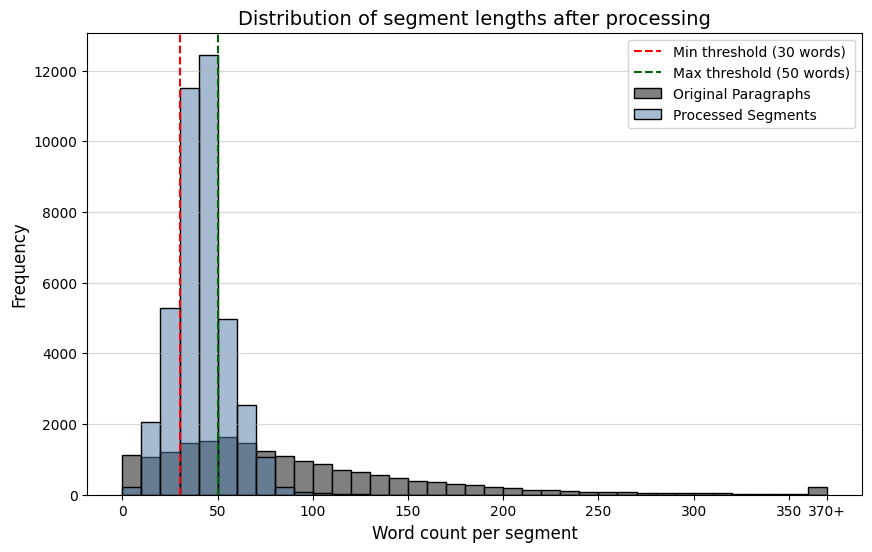

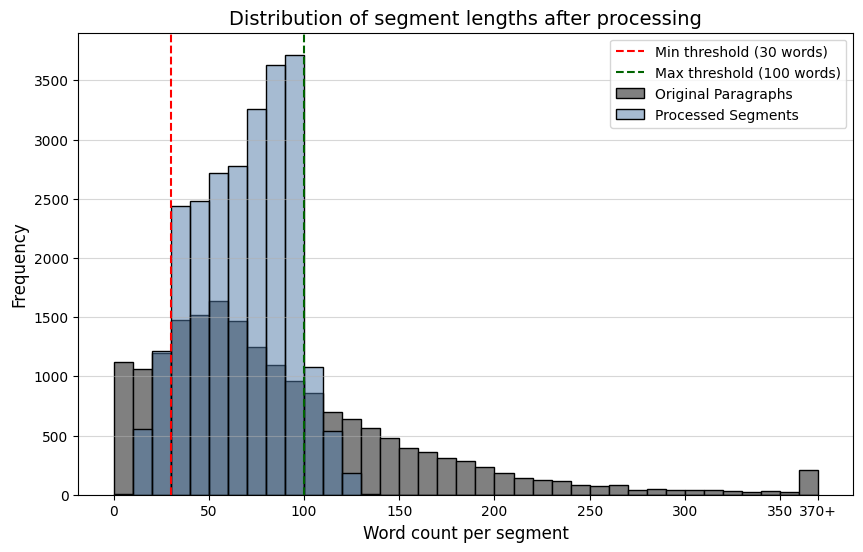

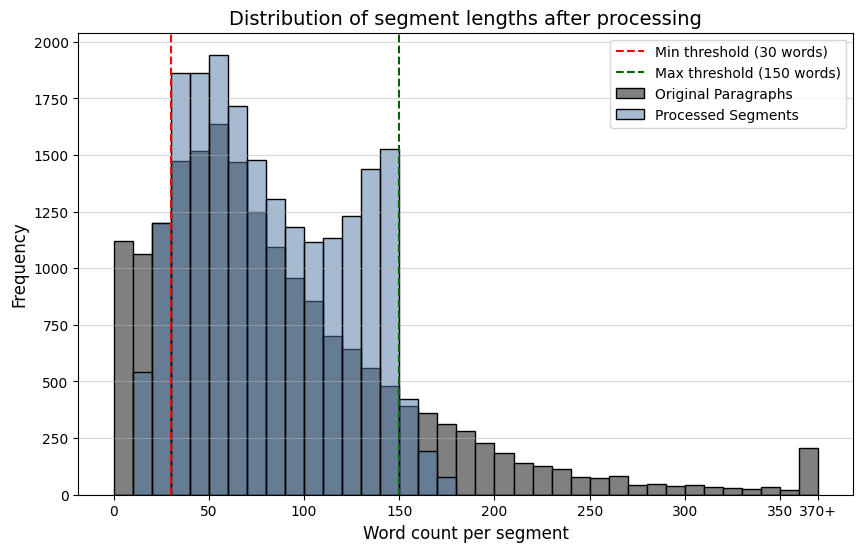

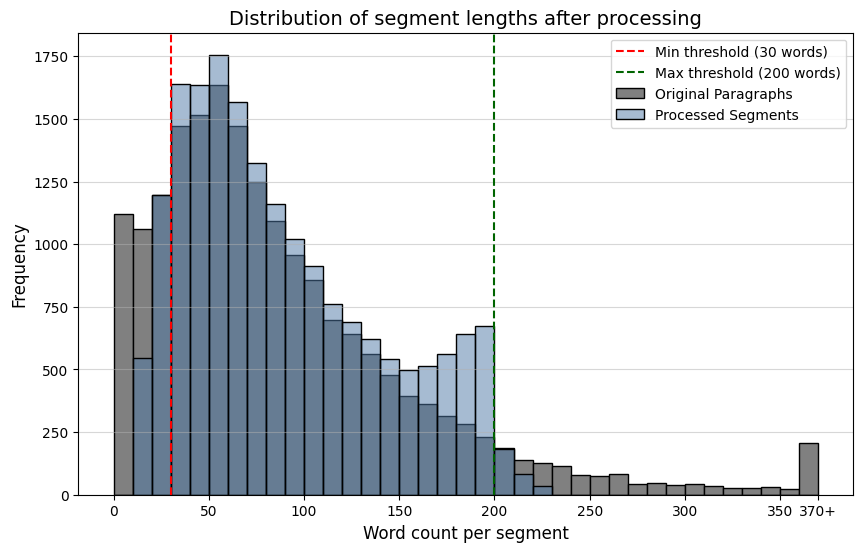

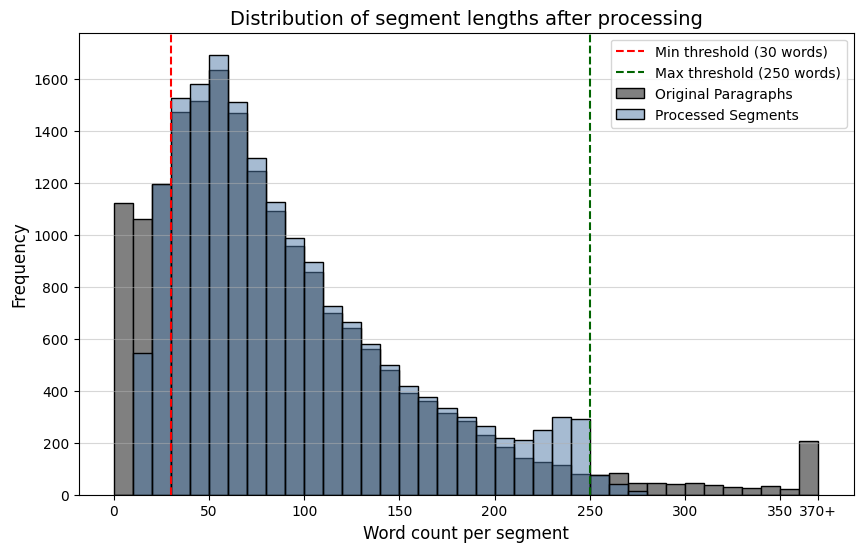

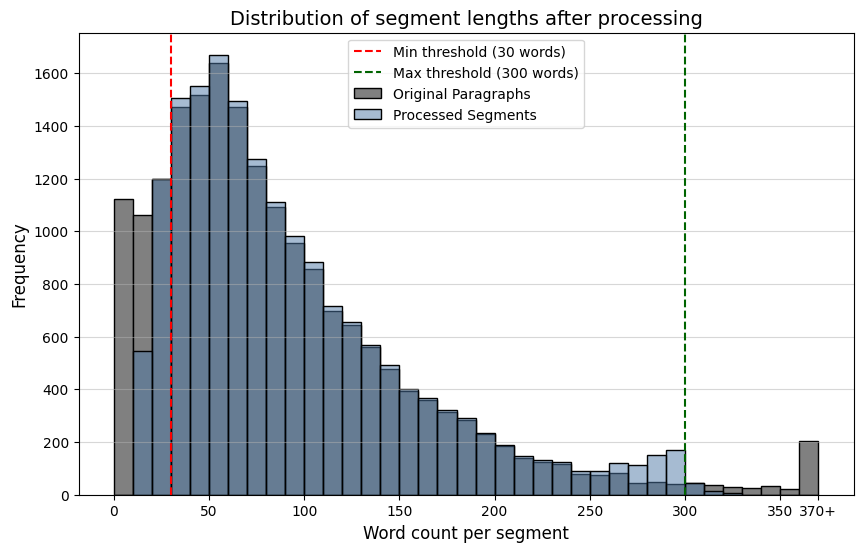

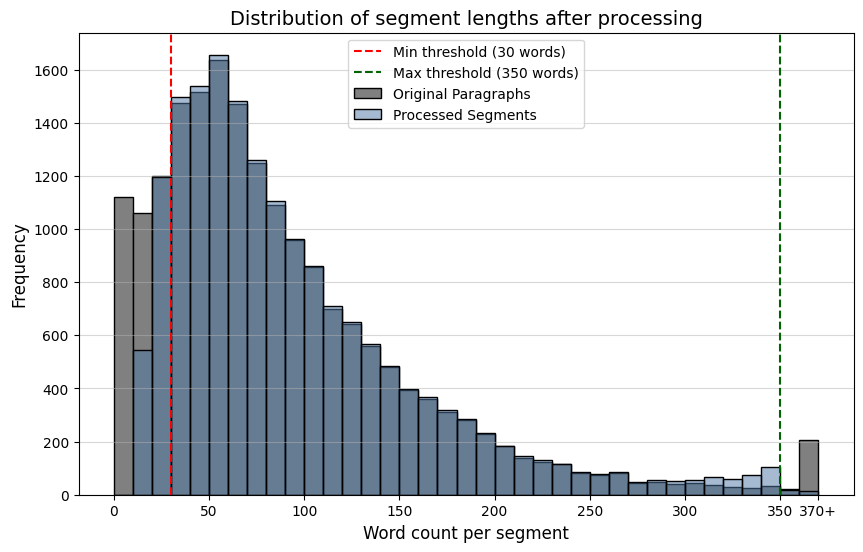

In [50]:
print("========= PARAGRAPHS =========")
print(paragraphs.describe())
LIMIT = 150
new_chunks = chunks.query(f"chunk_limit == {LIMIT}")[["date", "length"]]
print("========= CHUNKS =============")
print(new_chunks.describe())
for LIMIT in range(50,351,50):
    # 1. Spravíme si kópie dát, aby sme si nepokazili originály
    original_clipped = np.clip(paragraphs_lengths, a_min=None, a_max=370)
    processed_clipped = np.clip(chunks.query(f"chunk_limit == {LIMIT}")["length"], a_min=None, a_max=370)

    # 2. Nastavíme intervaly (bins) - posledný končí presne na 250
    moje_intervaly = np.arange(0, 380, 10)

    plt.figure(figsize=(10, 6))

    # 3. Vykreslíme to
    sns.histplot(original_clipped, bins=moje_intervaly, color='grey', alpha=1, label='Original Paragraphs')
    sns.histplot(processed_clipped, bins=moje_intervaly, color='#4e79a7', alpha=0.5, label='Processed Segments', edgecolor='black')

    # 4. Úprava osi X, aby bolo jasné, že posledný bin je "špeciálny"
    plt.xticks(list(range(0, 370, 50)) + [370], [str(x) for x in range(0, 370, 50)] + ['370+'])

    plt.axvline(30, color='red', linestyle='--', label='Min threshold (30 words)')
    plt.axvline(LIMIT, color='darkgreen', linestyle='--', label=f'Max threshold ({LIMIT} words)')

    plt.xlabel('Word count per segment', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Distribution of segment lengths after processing', fontsize=14)
    plt.legend()
    plt.grid(axis='y', alpha=0.5)
    # plt.savefig(f'{OUTPUT}/data/segment_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
